<a href="https://colab.research.google.com/github/sathu0622/DL_Assigment/blob/feature%2Fsathushan/Transfer_Learning_(MobileNetV2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction**

This project applies Transfer Learning to classify images from the Fashion MNIST dataset — a collection of 70,000 grayscale images of 10 clothing categories.

Transfer Learning leverages a pre-trained model (MobileNetV2) that has already learned rich feature representations from a large dataset (ImageNet). By fine-tuning this model on Fashion MNIST:

We save training time and computational resources.

The model can achieve high accuracy quickly because it uses features already learned in the pre-training phase.

In this implementation:

Images are resized and converted to RGB to match MobileNetV2 input requirements.

Data augmentation is applied to improve generalization.

The last layers of MobileNetV2 are fine-tuned for Fashion MNIST classification.

A learning rate scheduler and early stopping are used to improve training stability and performance.

### **Import Required Libraries**

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt


# **Load Fashion-MNIST Dataset**

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

IMG_SIZE = 96  # larger input size for MobileNetV2


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# **Preprocess Function**

In [4]:
def preprocess(image, label):
    image = tf.expand_dims(image, -1)                  # add channel dimension
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])  # resize to MobileNetV2 input
    image = tf.image.grayscale_to_rgb(image)          # convert grayscale to RGB
    image = tf.cast(image, tf.float32) / 255.0        # normalize
    return image, label


# **Data Pipeline**

In [5]:
BATCH_SIZE = 64

train_ds = (tf.data.Dataset.from_tensor_slices((x_train, y_train))
            .shuffle(10000)
            .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

test_ds = (tf.data.Dataset.from_tensor_slices((x_test, y_test))
           .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
           .batch(BATCH_SIZE)
           .prefetch(tf.data.AUTOTUNE))


# **Data Augmentation**

In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
])


# **Load and Fine-Tune MobileNetV2**

In [7]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze early layers, fine-tune later layers
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


# **Learning Rate Scheduler & Build the Model**

In [8]:
initial_lr = 1e-4
lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=initial_lr,
    first_decay_steps=1000
)

model3 = models.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])


# **Compile the Model**

In [9]:
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# **Train the Model**

In [10]:
history3 = model3.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)]
)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 75s 62ms/step - accuracy: 0.6887 - loss: 0.9667 - val_accuracy: 0.8456 - val_loss: 0.4673
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 56s 60ms/step - accuracy: 0.8340 - loss: 0.4848 - val_accuracy: 0.8775 - val_loss: 0.3575
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 59ms/step - accuracy: 0.8691 - loss: 0.3697 - val_accuracy: 0.8955 - val_loss: 0.2885
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 85s 62ms/step - accuracy: 0.8776 - loss: 0.3454 - val_accuracy: 0.8794 - val_loss: 0.3389
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 55s 59ms/step - accuracy: 0.8814 - loss: 0.3277 - val_accuracy: 0.8903 - val_loss: 0.3059
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 56s 59ms/step - accuracy: 0.8959 - loss: 0.2872 - val_accuracy: 0.9039 - val_loss: 0.2628
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 55s 59ms/step - accuracy: 0.9041 - loss: 0.2606 - val_accuracy: 0.9086 - val_loss: 0.2489
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 56s 60ms/step - accuracy: 0.9052 - loss: 0.2585 - 

# **Evaluate Model Performance**

In [11]:
test_loss, test_acc = model3.evaluate(test_ds)
print(f"\n✅ Final Test Accuracy (Transfer Learning - Tuned): {test_acc:.4f}")


157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9106 - loss: 0.2468

✅ Final Test Accuracy (Transfer Learning - Tuned): 0.9086


# **Visualize Training Progress**

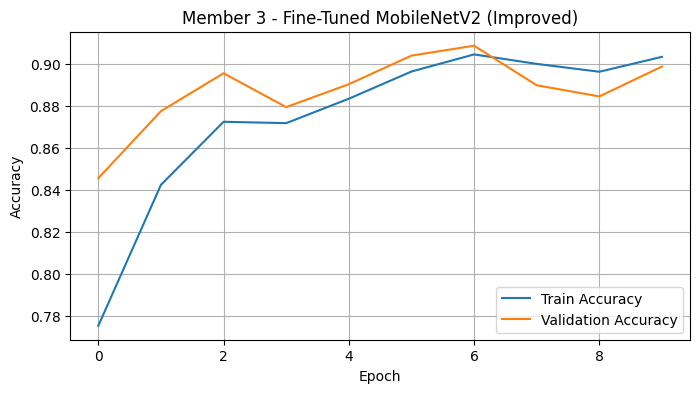

In [12]:
plt.figure(figsize=(8,4))
plt.plot(history3.history['accuracy'], label='Train Accuracy')
plt.plot(history3.history['val_accuracy'], label='Validation Accuracy')
plt.title("Member 3 - Fine-Tuned MobileNetV2 (Improved)")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()
